# Notebook 3 — Model Training (REVISED)

Changes from original:
1. **Data pipeline**: Loads `abrank_vh_vl_raw.csv` (saved by the data-prep revise notebook).
   - `sabdab_pretrain`: ALL rows with `log_Aff` not null, deduped on (vh, vl, Ag_seq), mean log_Aff.
   - `sabdab_finetune`: rows where same (vh_masked, vl, Ag_seq) scaffold has >1 unique HCDR3.
2. **Binding scorer architecture**: `ab_proj` replaces `cdr3_proj`; uses full (VH, VL) **seqcoding** (480d) not CDR3 mean-pool. No `forward_contrastive`, no `log_temp`.
3. **Stage 1**: MSE on `−log_Aff` with L=1 mean antigen token (~169k pairs).
4. **Stage 2**: MSE on `−log_Aff` with full per-residue antigen embeddings (~4k pairs).
5. **Quality check**: Spearman ρ on 10% validation split after Stage 2.
6. All outputs saved to `eval_inputs/`.

In [1]:
!pip install -q ablang2 torchcfm torchdiffeq scikit-learn scipy matplotlib
!pip install -q seaborn joblib fair-esm anarci requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.2 MB/s eta 0:00:00


In [2]:
import os, re, warnings, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, ks_2samp
from scipy.spatial.distance import cdist as scipy_cdist
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, train_test_split
import joblib

import esm
import ablang2

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs'
DATA_PATH   = f'{PROJECT_DIR}/GDPa1_v1.2_20250814.csv'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,    exist_ok=True)

CACHE = lambda name: f'{PROJECT_DIR}/{name}'

# ── Column names ───────────────────────────────────────────────────────────────
COL_VH    = 'vh_protein_sequence'
COL_VL    = 'vl_protein_sequence'
COL_HIC   = 'HIC'
COL_SINS  = 'AC-SINS_pH7.4'
COL_FOLD  = 'hierarchical_cluster_fold'
COL_AHO_H = 'heavy_aligned_aho'
COL_NAME  = 'antibody_name'

# ── Hyperparameters ────────────────────────────────────────────────────────────
TEST_FOLD          = 1
N_FLOW_SAMPLES     = 50
N_ODE_STEPS        = 100
M_SEQUENCES        = 20
TEMPERATURE        = 1.0
FLOW_EPOCHS        = 1000
CURRENT_SIGMA      = 0.5
PLS_COMPONENTS     = 10
AA_VOCAB           = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX          = {aa: i for i, aa in enumerate(AA_VOCAB)}
ABLANG_MASK        = '*'

# Binding scorer
SCORER_HIDDEN      = 128
SCORER_HEADS       = 4
SCORER_STAGE1_EP   = 100   # MSE on all log_Aff-labeled AbRank pairs (L=1 antigen)
SCORER_STAGE2_EP   = 50    # fine-tune on multi-variant pairs (per-residue antigen)
SCORER_STAGE1_BATCH= 64    # memory-cheap for L=1
SCORER_STAGE2_BATCH= 16    # memory-intensive for L=512
ANTIGEN_MAX_LEN    = 512
GUIDANCE_LAMBDA    = 0.5
ESM2_DIM           = 1280

# ── Cache paths ────────────────────────────────────────────────────────────────
MEAN_CACHE         = f'{EVAL_DIR}/antigen_esm2_embs.npy'
RESID_CACHE        = f'{EVAL_DIR}/antigen_esm2_resid.npy'
MASK_CACHE         = f'{EVAL_DIR}/antigen_valid_mask.npy'
RESID_PAD_CACHE    = f'{EVAL_DIR}/antigen_resid_pad_mask.npy'
SAB_MEAN_CACHE     = f'{EVAL_DIR}/sabdab_ag_mean_embs.npy'   # (N_stage1, 1280) ESM2 mean
SAB_AB_CACHE       = f'{EVAL_DIR}/sabdab_ab_seqcoding_embs.npy'  # (N_stage1, 480) seqcoding
SAB_FT_AB_CACHE    = f'{EVAL_DIR}/sabdab_ft_ab_seqcoding_embs.npy'
SAB_FT_RESID_CACHE = f'{EVAL_DIR}/sabdab_ft_resid_embs.npy'
SAB_FT_MASK_CACHE  = f'{EVAL_DIR}/sabdab_ft_resid_masks.npy'
print('Paths configured.')

Mounted at /content/drive
Paths configured.


# ─────────────────────────────────────────────────────────────────────────────
# Section 1 — Reload artifacts from Notebooks 1 & 2
# ─────────────────────────────────────────────────────────────────────────────

In [4]:
import ast

df          = pd.read_csv(f'{PROJECT_DIR}/clinical_mabs_with_antigens.csv')
oracle_hic  = joblib.load(CACHE('oracle_hic.pkl'))
oracle_sins = joblib.load(CACHE('oracle_sins.pkl'))
full_scaler = joblib.load(CACHE('full_scaler.pkl'))
pls         = joblib.load(CACHE('pls_model.pkl'))
pls_scaler  = joblib.load(CACHE('pls_scaler.pkl'))
dev_scaler  = joblib.load(CACHE('dev_scaler.pkl'))

data         = np.load(CACHE('flow_model_inputs.npz'), allow_pickle=True)
X_pls_tr_sc  = data['X_pls_tr_sc']
X_pls_te_sc  = data['X_pls_te_sc']
X_fw_tr      = data['X_fw_tr']
X_fw_te      = data['X_fw_te']
y_hic_train  = data['y_hic_train']
y_sins_train = data['y_sins_train']
test_idx     = data['test_idx'].tolist()
train_idx    = data['train_idx'].tolist()

PLS_DIM = X_pls_tr_sc.shape[1]
FW_DIM  = X_fw_tr.shape[1]

for col in ['h_cdr3_idx', 'h_fw_idx']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# PLS inverse (for ODE guidance at generation time)
if hasattr(pls, 'x_mean_'):
    pls_x_mean = pls.x_mean_; pls_x_loadings = pls.x_loadings_
elif hasattr(pls, '_x_mean'):
    pls_x_mean = pls._x_mean; pls_x_loadings = pls.x_loadings_
else:
    pls_x_mean     = np.load(CACHE('pls_mean.npy'))
    pls_x_loadings = np.load(CACHE('pls_loadings_T.npy')).T

PLS_LOADINGS_T  = torch.tensor(pls_x_loadings.T,  dtype=torch.float32).to(DEVICE)
PLS_MEAN        = torch.tensor(pls_x_mean,          dtype=torch.float32).to(DEVICE)
PLS_SCALER_STD  = torch.tensor(pls_scaler.scale_,   dtype=torch.float32).to(DEVICE)
PLS_SCALER_MEAN = torch.tensor(pls_scaler.mean_,    dtype=torch.float32).to(DEVICE)

def inverse_pls_torch(x_pls_scaled):
    x_raw = x_pls_scaled * PLS_SCALER_STD + PLS_SCALER_MEAN
    return x_raw @ PLS_LOADINGS_T + PLS_MEAN

print(f'Reloaded: PLS_DIM={PLS_DIM}  FW_DIM={FW_DIM}')
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Reloaded: PLS_DIM=10  FW_DIM=480
Train: 196  Test: 50


# ─────────────────────────────────────────────────────────────────────────────
# Section 2 — Build sabdab_pretrain and sabdab_finetune from abrank_vh_vl_raw.csv
#
# sabdab_pretrain : ALL rows where log_Aff is not null, deduped on (vh, vl, Ag_seq)
# sabdab_finetune : rows where same (vh_masked, vl, Ag_seq) has >1 unique HCDR3
# ─────────────────────────────────────────────────────────────────────────────

In [5]:
# Load the raw AbRank data with vh/vl columns (saved by the data-prep revise notebook)
df_test_check = pd.read_csv(f'{PROJECT_DIR}/abrank_vh_vl_raw.csv')
print(f'Loaded abrank_vh_vl_raw.csv: {len(df_test_check):,} rows')
print(f'Columns: {df_test_check.columns.tolist()}')

# ── Stage 1: all rows with log_Aff, deduped on (vh, vl, Ag_seq) ──────────────
# log_Aff is already log-transformed — do NOT apply log10 again
sabdab_pretrain = (
    df_test_check[df_test_check['log_Aff'].notna()]
    .groupby(['vh', 'vl', 'Ag_seq'], as_index=False)
    .agg({'log_Aff': 'mean', 'hcdr3': 'first'})
    .reset_index(drop=True)
)

# ── Stage 2: multi-variant groups (same scaffold+Ag, >1 unique HCDR3) ─────────
# Build framework key: mask HCDR3 with '*' chars
labeled = df_test_check[df_test_check['log_Aff'].notna()].copy()
labeled['vh_masked'] = labeled.apply(
    lambda r: r['vh'].replace(r['hcdr3'], '*' * len(r['hcdr3']), 1)
    if isinstance(r['vh'], str) and isinstance(r['hcdr3'], str) else r['vh'],
    axis=1
)

groups = labeled.groupby(['vh_masked', 'vl', 'Ag_seq'])
sabdab_finetune = groups.filter(
    lambda g: g['hcdr3'].nunique() > 1
).reset_index(drop=True)

# ── Diagnostics ───────────────────────────────────────────────────────────────
print(f'Total rows:                   {len(df_test_check):,}')
print(f'Rows with log_Aff:            {df_test_check["log_Aff"].notna().sum():,}')
print(f'Stage 1 (pretrain) rows:      {len(sabdab_pretrain):,}')
print(f'Stage 2 (finetune) rows:      {len(sabdab_finetune):,}')
print(f'Stage 2 multi-variant groups: '
      f'{sabdab_finetune.groupby(["vh_masked","vl","Ag_seq"]).ngroups:,}')
print(f'log_Aff range: [{sabdab_pretrain["log_Aff"].min():.2f}, '
      f'{sabdab_pretrain["log_Aff"].max():.2f}]')

# ── Save CSVs ─────────────────────────────────────────────────────────────────
sabdab_pretrain.to_csv(f'{PROJECT_DIR}/abrank_stage1.csv', index=False)
sabdab_finetune.to_csv(f'{PROJECT_DIR}/abrank_stage2.csv', index=False)
# Also save to eval_inputs for easy access
sabdab_pretrain.to_csv(f'{EVAL_DIR}/abrank_stage1.csv', index=False)
sabdab_finetune.to_csv(f'{EVAL_DIR}/abrank_stage2.csv', index=False)
print('Saved: abrank_stage1.csv, abrank_stage2.csv')

Loaded abrank_vh_vl_raw.csv: 169,236 rows
Columns: ['Ab_name', 'Ag_name', 'Ag_name_details', 'IC50 [ug/mL]', 'Affinity_Kd [nM]', 'Ag_epitope_restrictions', 'Ab_heavy_chain_seq', 'Ab_light_chain_seq', 'Ag_seq', 'Ab_structure_method', 'Ag_structure_method', 'bound_AbAg_structure_method', 'Ab_PDB_ID', 'Ag_PDB_ID', 'bound_AbAg_PDB_ID', 'Ab_Lev3_cluster', 'Source', 'escape', 'log(Kd_ratio)', 'Ab10_cluster', 'Ab25_cluster', 'Ab50_cluster', 'Ag_Lev3_cluster', 'Ag10_cluster', 'Ag25_cluster', 'Ag50_cluster', 'log_Aff', 'Aff_op', 'hc_clean', 'lc_clean', 'heavy_aligned_aho', 'ligt_aligned_aho', 'hcdr3', 'hcdr3_len', 'vh', 'vl']
Total rows:                   169,236
Rows with log_Aff:            169,236
Stage 1 (pretrain) rows:      167,114
Stage 2 (finetune) rows:      8,007
Stage 2 multi-variant groups: 1,279
log_Aff range: [-4.15, 4.96]
Saved: abrank_stage1.csv, abrank_stage2.csv


# ─────────────────────────────────────────────────────────────────────────────
# Section 3 — Flow Model Architecture & Training  (unchanged from original)
# ─────────────────────────────────────────────────────────────────────────────

In [6]:
class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        t    = t.view(-1, 1).float()
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) *
            torch.arange(half, device=t.device).float() / (half - 1))
        args = t * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)


class CDR3VelocityNetPLS(nn.Module):
    def __init__(self, pls_dim=10, fw_dim=480, dev_dim=2,
                 hidden=128, t_dim=32, drop=0.2):
        super().__init__()
        self.t_emb    = SinusoidalTimeEmbed(t_dim)
        self.fw_proj  = nn.Sequential(
            nn.Linear(fw_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden * 2))
        self.dev_proj = nn.Sequential(
            nn.Linear(dev_dim, 32), nn.GELU(),
            nn.Linear(32, hidden))
        inp       = pls_dim + t_dim
        self.l1   = nn.Linear(inp, hidden)
        self.n1   = nn.LayerNorm(hidden)
        self.l2   = nn.Linear(hidden, hidden)
        self.n2   = nn.LayerNorm(hidden)
        self.out  = nn.Linear(hidden, pls_dim)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(drop)

    def forward(self, t, x, fw, dev_target):
        if t.dim() == 0: t = t.expand(x.shape[0])
        t_e            = self.t_emb(t)
        h              = torch.cat([x, t_e], dim=-1)
        fw_scale, fw_b = self.fw_proj(fw).chunk(2, dim=-1)
        dev_e          = self.dev_proj(dev_target)
        h  = self.drop(self.act(self.n1(self.l1(h))))
        h  = h * (1 + fw_scale) + fw_b
        h  = h + dev_e
        h  = self.drop(self.act(self.n2(self.l2(h))))
        return self.out(h)

flow_model = CDR3VelocityNetPLS(pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)
n_params = sum(p.numel() for p in flow_model.parameters())
print(f'Flow model: {n_params:,} parameters  (working in {PLS_DIM}d PLS space)')

Flow model: 122,730 parameters  (working in 10d PLS space)


In [7]:
dev_scaler   = StandardScaler()
dev_train_sc = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))

In [8]:
def augment(Xp, Xf, dev, n_aug=5, noise_p=0.05, noise_f=0.01):
    ps, fs, ds = [Xp], [Xf], [dev]
    for _ in range(n_aug):
        ps.append(Xp + np.random.normal(0, noise_p, Xp.shape))
        fs.append(Xf + np.random.normal(0, noise_f, Xf.shape))
        ds.append(dev)
    return np.vstack(ps), np.vstack(fs), np.vstack(ds)

Xp_aug, Xf_aug, dev_aug = augment(X_pls_tr_sc, X_fw_tr, dev_train_sc, n_aug=5)
print(f'Augmented training set: {Xp_aug.shape}  (original: {X_pls_tr_sc.shape})')

ds = TensorDataset(
    torch.tensor(Xp_aug,  dtype=torch.float32),
    torch.tensor(Xf_aug,  dtype=torch.float32),
    torch.tensor(dev_aug, dtype=torch.float32))
loader = DataLoader(ds, batch_size=32, shuffle=True)

Augmented training set: (1176, 10)  (original: (196, 10))


Checkpoint found — loading from /content/drive/MyDrive/2026 Spring/BMI 702/project/flow_model_pls_sigma0.5.pt


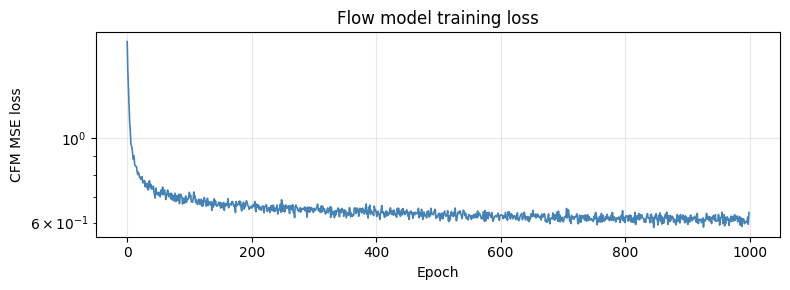

In [9]:
FLOW_CKPT = CACHE(f'flow_model_pls_sigma{CURRENT_SIGMA}.pt')

flow_model = CDR3VelocityNetPLS(pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)

if os.path.exists(FLOW_CKPT):
    print(f'Checkpoint found — loading from {FLOW_CKPT}')
    flow_model.load_state_dict(torch.load(FLOW_CKPT, map_location=DEVICE))
    losses = np.load(CACHE('flow_losses.npy')).tolist()
else:
    FM  = ConditionalFlowMatcher(sigma=CURRENT_SIGMA)
    opt = AdamW(flow_model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=FLOW_EPOCHS, eta_min=1e-5)
    losses = []

    print(f'Training flow model in {PLS_DIM}d PLS space (sigma={CURRENT_SIGMA})...')
    for epoch in range(FLOW_EPOCHS):
        flow_model.train()
        ep = 0.0
        for x1, fw, dev in loader:
            x1, fw, dev = x1.to(DEVICE), fw.to(DEVICE), dev.to(DEVICE)
            x0          = torch.randn_like(x1)
            t, xt, ut   = FM.sample_location_and_conditional_flow(x0, x1)
            vt          = flow_model(t, xt, fw, dev)
            loss        = F.mse_loss(vt, ut)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
            opt.step(); ep += loss.item()
        sch.step()
        losses.append(ep / len(loader))
        if (epoch + 1) % 200 == 0:
            print(f'  Epoch {epoch+1:4d} | CFM loss: {losses[-1]:.5f}')

    torch.save(flow_model.state_dict(), FLOW_CKPT)
    np.save(CACHE('flow_losses.npy'), np.array(losses))
    print(f'Saved → {FLOW_CKPT}')

flow_model.eval()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, lw=1.2, color='steelblue')
ax.set(xlabel='Epoch', ylabel='CFM MSE loss', yscale='log',
       title='Flow model training loss')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Section 4 — AbLang2 + ESM2 setup, embedding helpers
# ─────────────────────────────────────────────────────────────────────────────

In [10]:
print('Loading AbLang2 paired model (frozen)...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                            random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()
print('AbLang2 loaded.')

@torch.no_grad()
def get_ab_seqcoding(vh, vl):
    """AbLang2 seqcoding of full (VH, VL) pair → 480d numpy vector."""
    emb = ablang([(str(vh), str(vl))], mode='seqcoding')
    return np.array(emb).reshape(480)

print('get_ab_seqcoding() helper defined.')

Loading AbLang2 paired model (frozen)...
AbLang2 loaded.
get_ab_seqcoding() helper defined.


In [11]:
# ── ESM2-650M setup ────────────────────────────────────────────────────────────
print('Loading ESM2-650M...')
esm2_model, esm2_alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm2_model = esm2_model.to(DEVICE).eval()
esm2_batch_converter = esm2_alphabet.get_batch_converter()
print('ESM2 loaded.')

#@torch.no_grad()
#def embed_esm2(seq, max_len=1022):
#    """ESM2-650M → (mean_1280d, residue_array_L×1280)."""
#    seq = seq[:max_len]
#    _, _, tokens = esm2_batch_converter([('s', seq)])
#    out  = esm2_model(tokens.to(DEVICE), repr_layers=[33])
#    reps = out['representations'][33][0, 1:-1, :].cpu().numpy()
#    return reps.mean(0), reps

@torch.no_grad()
def embed_esm2(seq, max_len=1022):
    """ESM2-650M → (mean_1280d, residue_array_L×1280)."""
    # Sanitize before tokenization
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWYX]', 'X', seq.upper().strip())
    seq = seq[:max_len]
    if len(seq) == 0:
        raise ValueError("Empty sequence after sanitization")
    _, _, tokens = esm2_batch_converter([('s', seq)])
    out  = esm2_model(tokens.to(DEVICE), repr_layers=[33])
    reps = out['representations'][33][0, 1:-1, :].cpu().numpy()
    return reps.mean(0), reps

print('embed_esm2() helper defined.')

Loading ESM2-650M...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
ESM2 loaded.
embed_esm2() helper defined.


# ─────────────────────────────────────────────────────────────────────────────
# Section 5 — CrossAttentionBindingScorer Architecture (REVISED)
#
# Key changes vs original:
#   - ab_proj  replaces  cdr3_proj  (input is full 480d seqcoding)
#   - forward_contrastive removed (no InfoNCE)
#   - log_temp removed
#   - forward_score is the ONLY scoring path
# ─────────────────────────────────────────────────────────────────────────────

In [12]:
class CrossAttentionBindingScorer(nn.Module):
    def __init__(self, ab_dim=480, ag_dim=ESM2_DIM,
                 hidden=SCORER_HIDDEN, n_heads=SCORER_HEADS, dropout=0.1):
        super().__init__()
        self.ab_proj    = nn.Sequential(
            nn.Linear(ab_dim, hidden, bias=False), nn.LayerNorm(hidden))
        self.ag_proj    = nn.Sequential(
            nn.Linear(ag_dim, hidden, bias=False), nn.LayerNorm(hidden))
        self.cross_attn = nn.MultiheadAttention(
            hidden, n_heads, dropout=dropout, batch_first=True)
        self.score_head = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward_score(self, ab_emb, ag_residues, ag_key_padding_mask=None):
        """
        ab_emb              : (B, 480)      full seqcoding of (VH, VL)
        ag_residues         : (B, L, 1280)  L=1 for stage1, L≤512 for stage2
        ag_key_padding_mask : (B, L) bool   True = padding (ignored)
        Returns             : (B,) predicted −log_Aff scores
        """
        q          = self.ab_proj(ab_emb).unsqueeze(1)          # (B, 1, 128)
        kv         = self.ag_proj(ag_residues)                   # (B, L, 128)
        context, _ = self.cross_attn(
            q, kv, kv, key_padding_mask=ag_key_padding_mask)    # (B, 1, 128)
        combined   = torch.cat([q.squeeze(1), context.squeeze(1)], dim=-1)
        return self.score_head(combined).squeeze(-1)              # (B,)

binding_scorer = CrossAttentionBindingScorer().to(DEVICE)
n_params = sum(p.numel() for p in binding_scorer.parameters())
print(f'CrossAttentionBindingScorer: {n_params:,} parameters')
print('  ab_proj input: 480d seqcoding of full (VH, VL)')
print('  ag_proj input: 1280d ESM2 per-residue (L=1 for Stage1, L≤512 for Stage2)')

CrossAttentionBindingScorer: 324,865 parameters
  ab_proj input: 480d seqcoding of full (VH, VL)
  ag_proj input: 1280d ESM2 per-residue (L=1 for Stage1, L≤512 for Stage2)


# ─────────────────────────────────────────────────────────────────────────────
# Section 6 — Stage 1: MSE on log_Aff (L=1 antigen token, ~169k pairs)
# ─────────────────────────────────────────────────────────────────────────────

In [13]:
# ── 6a: Antibody seqcoding embeddings for Stage 1 (cached) ───────────────────
N_s1 = len(sabdab_pretrain)

if os.path.exists(SAB_AB_CACHE):
    sab_ab_embs = np.load(SAB_AB_CACHE)
    print(f'Loaded Stage 1 seqcoding embs: {sab_ab_embs.shape}')
else:
    print(f'Computing AbLang2 seqcoding for {N_s1:,} Stage 1 pairs...')
    BATCH = 16
    sab_ab_list = []
    for i in range(0, N_s1, BATCH):
        rows = sabdab_pretrain.iloc[i:i+BATCH]
        seqs = list(zip(rows['vh'], rows['vl']))
        try:
            with torch.no_grad():
                embs = ablang(seqs, mode='seqcoding')
            sab_ab_list.append(np.array(embs).reshape(len(seqs), 480))
        except Exception as e:
            print(f'  Error at batch {i}: {e}')
            sab_ab_list.append(np.zeros((len(seqs), 480)))
        if i % 5000 == 0:
            print(f'  {min(i+BATCH, N_s1):,}/{N_s1:,}')
    sab_ab_embs = np.vstack(sab_ab_list)
    np.save(SAB_AB_CACHE, sab_ab_embs)
    print(f'Saved: {sab_ab_embs.shape}')

print(f'Stage 1 antibody seqcoding: {sab_ab_embs.shape}')

Computing AbLang2 seqcoding for 167,114 Stage 1 pairs...
  16/167,114
  10,016/167,114
  20,016/167,114
  30,016/167,114
  40,016/167,114
  50,016/167,114
  60,016/167,114
  70,016/167,114
  80,016/167,114
  90,016/167,114
  100,016/167,114
  110,016/167,114
  120,016/167,114
  130,016/167,114
  140,016/167,114
  150,016/167,114
  160,016/167,114
Saved: (167114, 480)
Stage 1 antibody seqcoding: (167114, 480)


In [15]:
import re

VALID_ESM2_AA = set("ACDEFGHIKLMNPQRSTVWYX")  # X is supported as unknown

def sanitize_ag_seq(seq):
    """Uppercase, replace non-ESM2 chars with X, return None if empty/invalid."""
    if not isinstance(seq, str) or len(seq.strip()) == 0:
        return None
    seq = seq.upper().strip()
    # Replace any character not in ESM2 vocabulary with 'X' (masked/unknown)
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWYX]', 'X', seq)
    return seq if len(seq) > 0 else None

In [16]:
#unique_ags_s1

array(['MEIRKNYQHLWRWGIMLLWLLMSCSAEEEAWVTVYYGVPVWKEAVTTLFCASDAKAYDTEVHNVWTTHACVPTDPDPQEVHMENVTEDFNMWKNNMADQMHEDIISLWDQSLKPCVKLTPLCVTLNCADWKNNTDTNTNSSVRIMEKGEIKNCSFNITTNIRDKYQKAYALFYKLDVVPIDDDNATGNNDTRNYRLISCNTSVITQACPKVSFEPIPIHYCAPAGFAILRCNNKTFSGKGQCTNVSTVQCTHGIKPVVSTQLLLNGSLAEEEVIIRSDNFSDNAKTIIVHLNSSVDINCTRPGNNTRKSITIGPGRAFYATGDIIGDIRQAHCNISGEKWNNTLKQVVKKLREQFGNKTIVFNQSSGGDPEITMHTFNCGGEFFYCNTAQLFNSTWEANSTWENDNERVGHSNKTIILQCRIKQIINMWQEVGKAMYAPPISGQIRCSSNITGLLLTRDGGNGNETNRTEVFRPGGGNMKDNWRSELYKYKVVKIEPLGVAPTRAKRRVVQREKRAVGMGALFIGFLSAAGSTMGAASMTLTVQARQLLSGIVQQQSNLLRAIEAQQHLLQLTVWGIKQLQARVLAVERYLKDQQLLGIWGCSGKLICTTTVPWNYSWSPNKTMDDIWGNMTWMQWEREIDNYTGIIYRLIEISQNQQEKNEQELLELDKWASLWNWFDITKWLWYIKIFIMIIGGLVGLRIVFTVLSIVNRVRQGYSPLSFQTRFPAPGGPDRPEGTEEEGGERDRDRSSRSADGFLAIIWVDLRSLCLFIYHSLRDLLLIVARIVGLLGRRGWELLKYWWNLLQYWSQELKNSAVSLLNATAIAVAEGTDRVIDIVQRICRAILHIPRRIRQGFERALL',
       'MEIRRNYQHLWRWGTMLLGLLMICNAAEQLWVTVYYGVPVWREANTTLFCASDAKSYDTEVHNVWATHACVPTDPNPQEVVMGNVTESFNMWKNHMVEQMHEDIISLWDQSLKPCVRLTP

In [18]:
# ── 6b: ESM2 mean-pool antigen embeddings for Stage 1 (cache by unique Ag_seq) ──
# Mean antigen embedding used as single token (L=1) — memory-efficient for ~169k pairs.
# Per-residue embeddings at Stage 1 scale would require ~440 GB.

if os.path.exists(SAB_MEAN_CACHE):
    sab_ag_mean_embs = np.load(SAB_MEAN_CACHE)
    print(f'Loaded Stage 1 antigen mean embs: {sab_ag_mean_embs.shape}')
else:
    unique_ags_s1 = sabdab_pretrain['Ag_seq'].unique()
    print(f'Computing ESM2 mean embeddings for {len(unique_ags_s1):,} unique antigens...')
    ag_mean_dict = {}
    #for idx_ag, ag_seq in enumerate(unique_ags_s1):
    #    try:
    #        mean_v, _ = embed_esm2(str(ag_seq))
    #        ag_mean_dict[ag_seq] = mean_v
    #    except Exception as e:
    #        print(f'  ESM2 error [{idx_ag}]: {e}')
    #        ag_mean_dict[ag_seq] = np.zeros(ESM2_DIM, dtype=np.float32)
    #    if (idx_ag + 1) % 1000 == 0:
    #        print(f'  {idx_ag+1:,}/{len(unique_ags_s1):,} antigens embedded...')
    for idx_ag, ag_seq in enumerate(unique_ags_s1):
      cleaned = sanitize_ag_seq(str(ag_seq))
      try:
          if cleaned is None:
              raise ValueError(f"Empty/invalid seq after sanitization: {repr(ag_seq)[:40]}")
          mean_v, _ = embed_esm2(cleaned)
          ag_mean_dict[ag_seq] = mean_v
      except Exception as e:
          print(f'  ESM2 error [{idx_ag}]: {e} | raw: {repr(str(ag_seq)[:40])}')
          ag_mean_dict[ag_seq] = np.zeros(ESM2_DIM, dtype=np.float32)
      if (idx_ag + 1) % 1000 == 0:
          print(f'  {idx_ag+1:,}/{len(unique_ags_s1):,} antigens embedded...')

    sab_ag_mean_embs = np.stack([ag_mean_dict[ag] for ag in sabdab_pretrain['Ag_seq']])
    np.save(SAB_MEAN_CACHE, sab_ag_mean_embs)
    print(f'Saved: {sab_ag_mean_embs.shape}')

print(f'Stage 1 antigen mean embs: {sab_ag_mean_embs.shape}')

Computing ESM2 mean embeddings for 4,630 unique antigens...
  1,000/4,630 antigens embedded...
  2,000/4,630 antigens embedded...
  3,000/4,630 antigens embedded...
  4,000/4,630 antigens embedded...
Saved: (167114, 1280)
Stage 1 antigen mean embs: (167114, 1280)


In [30]:
# ── 6c: Stage 1 training — MSE on −log_Aff, L=1 antigen token ────────────────
# log_Aff is already log-transformed; do NOT apply log10 again.
# Target = −log_Aff so higher score = stronger predicted binding.

SCORER_STAGE1_CKPT = f'{EVAL_DIR}/binding_scorer_stage1.pt'

N_s1 = len(sabdab_pretrain)

# Reshape mean antigen embedding to single token for cross-attention
ag_s1_resid = sab_ag_mean_embs[:, np.newaxis, :]           # (N, 1, 1280)
ag_s1_mask  = np.zeros((N_s1, 1), dtype=bool)              # no padding

log_aff_s1  = sabdab_pretrain['log_Aff'].values.astype(np.float32)  # already log

# 90/10 train/val split
idx_tr_s1, idx_val_s1 = train_test_split(
    np.arange(N_s1), test_size=0.1, random_state=42)

if os.path.exists(SCORER_STAGE1_CKPT):
    binding_scorer.load_state_dict(
        torch.load(SCORER_STAGE1_CKPT, map_location=DEVICE))
    binding_scorer.eval()
    print('Loaded Stage 1 scorer from cache.')
else:
    print(f'Stage 1 — MSE on log_Aff for {len(idx_tr_s1):,} pairs...')

    ds_s1 = TensorDataset(
        torch.tensor(sab_ab_embs[idx_tr_s1],   dtype=torch.float32),
        torch.tensor(ag_s1_resid[idx_tr_s1],    dtype=torch.float32),
        torch.tensor(ag_s1_mask[idx_tr_s1],     dtype=torch.bool),
        torch.tensor(log_aff_s1[idx_tr_s1],     dtype=torch.float32))
    loader_s1 = DataLoader(ds_s1, batch_size=SCORER_STAGE1_BATCH,
                           shuffle=True, drop_last=True)
    opt_s1 = AdamW(binding_scorer.parameters(), lr=2e-4, weight_decay=1e-4)
    sch_s1 = CosineAnnealingLR(opt_s1, T_max=SCORER_STAGE1_EP, eta_min=1e-6)

    binding_scorer.train()
    for epoch in range(SCORER_STAGE1_EP):
        ep = 0.0
        for ab_b, ag_r, ag_m, aff_b in loader_s1:
            score = binding_scorer.forward_score(
                ab_b.to(DEVICE), ag_r.to(DEVICE), ag_m.to(DEVICE))
            loss = F.mse_loss(score, -aff_b.to(DEVICE))  # target = −log_Aff
            opt_s1.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(binding_scorer.parameters(), 1.0)
            opt_s1.step(); ep += loss.item()
        sch_s1.step()
        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d} | MSE: {ep/len(loader_s1):.4f}')

    torch.save(binding_scorer.state_dict(), SCORER_STAGE1_CKPT)
    print(f'Saved → {SCORER_STAGE1_CKPT}')

# ── Stage 1 validation Spearman ρ ────────────────────────────────────────────
binding_scorer.eval()
with torch.no_grad():
    val_scores_s1 = binding_scorer.forward_score(
        torch.tensor(sab_ab_embs[idx_val_s1],  dtype=torch.float32).to(DEVICE),
        torch.tensor(ag_s1_resid[idx_val_s1],   dtype=torch.float32).to(DEVICE),
        torch.tensor(ag_s1_mask[idx_val_s1],    dtype=torch.bool).to(DEVICE)
    ).cpu().numpy()

rho_s1, p_s1 = spearmanr(val_scores_s1, -log_aff_s1[idx_val_s1])
print(f'Stage 1 validation Spearman ρ = {rho_s1:.3f}  p = {p_s1:.4f}')
print('(Useful scorer: ρ > 0.3)')

Stage 1 — MSE on log_Aff for 150,402 pairs...
  Epoch  20 | MSE: 0.9419
  Epoch  40 | MSE: 0.8735
  Epoch  60 | MSE: 0.8214
  Epoch  80 | MSE: 0.7801
  Epoch 100 | MSE: 0.7648
Saved → /content/drive/MyDrive/2026 Spring/BMI 702/project/eval_inputs/binding_scorer_stage1.pt
Stage 1 validation Spearman ρ = 0.768  p = 0.0000
(Useful scorer: ρ > 0.3)


In [32]:

import shutil
backup_path = f'{PROJECT_DIR}/binding_scorer_stage1_backup.pt'
shutil.copy(SCORER_STAGE1_CKPT, backup_path)
print(f'Backup saved to {backup_path}')

Backup saved to /content/drive/MyDrive/2026 Spring/BMI 702/project/binding_scorer_stage1_backup.pt


took around 20 min on A100, 100 epoch, MSE: 0.78 , validation spearman 0.765

# ─────────────────────────────────────────────────────────────────────────────
# Section 7 — Stage 2: Fine-tune on multi-variant pairs (per-residue antigen)
# ─────────────────────────────────────────────────────────────────────────────

In [20]:
# ── 7a: Antibody seqcoding embeddings for Stage 2 (cached) ───────────────────
N_s2 = len(sabdab_finetune)
print(f'Stage 2 finetune set: {N_s2:,} pairs')

if os.path.exists(SAB_FT_AB_CACHE):
    ft_ab_embs = np.load(SAB_FT_AB_CACHE)
    print(f'Loaded Stage 2 seqcoding embs: {ft_ab_embs.shape}')
else:
    print(f'Computing AbLang2 seqcoding for {N_s2:,} Stage 2 pairs...')
    BATCH = 16
    ft_ab_list = []
    for i in range(0, N_s2, BATCH):
        rows = sabdab_finetune.iloc[i:i+BATCH]
        seqs = list(zip(rows['vh'], rows['vl']))
        try:
            with torch.no_grad():
                embs = ablang(seqs, mode='seqcoding')
            ft_ab_list.append(np.array(embs).reshape(len(seqs), 480))
        except Exception as e:
            print(f'  Error at batch {i}: {e}')
            ft_ab_list.append(np.zeros((len(seqs), 480)))
        if i % 1000 == 0:
            print(f'  {min(i+BATCH, N_s2):,}/{N_s2:,}')
    ft_ab_embs = np.vstack(ft_ab_list)
    np.save(SAB_FT_AB_CACHE, ft_ab_embs)
    print(f'Saved: {ft_ab_embs.shape}')

Stage 2 finetune set: 8,007 pairs
Computing AbLang2 seqcoding for 8,007 Stage 2 pairs...
  16/8,007
  2,016/8,007
  4,016/8,007
  6,016/8,007
  8,007/8,007
Saved: (8007, 480)


In [23]:
# ── 7b: Per-residue antigen embeddings for Stage 2 (cache by unique Ag_seq) ───
# Cache by unique antigen to avoid redundant ESM2 calls across the multi-variant groups.

if os.path.exists(SAB_FT_RESID_CACHE) and os.path.exists(SAB_FT_MASK_CACHE):
    ft_resid = np.load(SAB_FT_RESID_CACHE)
    ft_masks = np.load(SAB_FT_MASK_CACHE)
    print(f'Loaded Stage 2 per-residue embs: {ft_resid.shape}')
else:
    unique_ag_ft = sabdab_finetune['Ag_seq'].unique()
    print(f'Computing ESM2 per-residue embeddings for {len(unique_ag_ft):,} unique antigens...')
    ag_resid_map, ag_mask_map = {}, {}
    #for idx_ag, ag in enumerate(unique_ag_ft):
    #    try:
    #        _, resid = embed_esm2(str(ag))
    #    except Exception as e:
    #        print(f'  ESM2 error [{idx_ag}]: {e}')
    #        resid = np.zeros((1, ESM2_DIM), dtype=np.float32)
    for idx_ag, ag in enumerate(unique_ag_ft):
      cleaned = sanitize_ag_seq(str(ag))
      try:
          if cleaned is None:
              raise ValueError(f"Empty/invalid seq after sanitization: {repr(ag)[:40]}")
          _, resid = embed_esm2(cleaned)          # ← use cleaned, not str(ag)
      except Exception as e:
          print(f'  ESM2 error [{idx_ag}]: {e} | raw: {repr(str(ag)[:40])}')
          resid = np.zeros((1, ESM2_DIM), dtype=np.float32)


      L      = min(len(resid), ANTIGEN_MAX_LEN)
      padded = np.zeros((ANTIGEN_MAX_LEN, ESM2_DIM), dtype=np.float32)
      padded[:L] = resid[:L]
      mask = np.ones(ANTIGEN_MAX_LEN, dtype=bool)
      mask[:L] = False   # False = real token, True = padding
      ag_resid_map[ag] = padded
      ag_mask_map[ag]  = mask

      if (idx_ag + 1) % 200 == 0:
          print(f'  {idx_ag+1:,}/{len(unique_ag_ft):,} antigens embedded...')

    ft_resid = np.stack([ag_resid_map[ag] for ag in sabdab_finetune['Ag_seq']])
    ft_masks = np.stack([ag_mask_map[ag]  for ag in sabdab_finetune['Ag_seq']])
    np.save(SAB_FT_RESID_CACHE, ft_resid)
    np.save(SAB_FT_MASK_CACHE,  ft_masks)
    print(f'Saved: {ft_resid.shape}')

print(f'Stage 2 per-residue embs: {ft_resid.shape}  masks: {ft_masks.shape}')

Computing ESM2 per-residue embeddings for 3 unique antigens...
Saved: (8007, 512, 1280)
Stage 2 per-residue embs: (8007, 512, 1280)  masks: (8007, 512)


In [27]:
# ── 7c: Stage 2 fine-tuning — MSE on −log_Aff, per-residue antigen ────────────
SCORER_FT_CKPT = f'{EVAL_DIR}/binding_scorer.pt'

log_aff_s2 = sabdab_finetune['log_Aff'].values.astype(np.float32)  # already log

# 90/10 train/val split
idx_tr_s2, idx_val_s2 = train_test_split(
    np.arange(N_s2), test_size=0.1, random_state=42)

if os.path.exists(SCORER_FT_CKPT):
    binding_scorer.load_state_dict(
        torch.load(SCORER_FT_CKPT, map_location=DEVICE))
    binding_scorer.eval()
    print('Loaded fine-tuned scorer from cache.')
else:
    print(f'Stage 2 — fine-tuning on {len(idx_tr_s2):,} multi-variant pairs...')
    print('  Learning rate: 5e-6  |  Batch: 16  |  Epochs: 50')

    ds_s2 = TensorDataset(
        torch.tensor(ft_ab_embs[idx_tr_s2], dtype=torch.float32),
        torch.tensor(ft_resid[idx_tr_s2],   dtype=torch.float32),
        torch.tensor(ft_masks[idx_tr_s2],   dtype=torch.bool),
        torch.tensor(log_aff_s2[idx_tr_s2], dtype=torch.float32))
    loader_s2 = DataLoader(ds_s2, batch_size=SCORER_STAGE2_BATCH, shuffle=True)
    opt_ft = AdamW(binding_scorer.parameters(), lr=5e-6, weight_decay=1e-4)
    sch_ft = CosineAnnealingLR(opt_ft, T_max=SCORER_STAGE2_EP, eta_min=1e-7)

    binding_scorer.train()
    for epoch in range(SCORER_STAGE2_EP):
        ep = 0.0
        for ab_b, ag_r, ag_m, aff_b in loader_s2:
            score = binding_scorer.forward_score(
                ab_b.to(DEVICE), ag_r.to(DEVICE), ag_m.to(DEVICE))
            loss = F.mse_loss(score, -aff_b.to(DEVICE))  # target = −log_Aff
            opt_ft.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(binding_scorer.parameters(), 1.0)
            opt_ft.step(); ep += loss.item()
        sch_ft.step()
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | MSE: {ep/len(loader_s2):.4f}')

    torch.save(binding_scorer.state_dict(), SCORER_FT_CKPT)
    print(f'Saved → {SCORER_FT_CKPT}')

# ── Stage 2 validation Spearman ρ ────────────────────────────────────────────
binding_scorer.eval()
with torch.no_grad():
    val_scores_s2 = binding_scorer.forward_score(
        torch.tensor(ft_ab_embs[idx_val_s2], dtype=torch.float32).to(DEVICE),
        torch.tensor(ft_resid[idx_val_s2],   dtype=torch.float32).to(DEVICE),
        torch.tensor(ft_masks[idx_val_s2],   dtype=torch.bool).to(DEVICE)
    ).cpu().numpy()

rho_s2, p_s2 = spearmanr(val_scores_s2, -log_aff_s2[idx_val_s2])
print(f'Stage 2 validation Spearman ρ = {rho_s2:.3f}  p = {p_s2:.4f}')
print('(Useful scorer: ρ > 0.3)')

Stage 2 — fine-tuning on 7,206 multi-variant pairs...
  Learning rate: 5e-6  |  Batch: 16  |  Epochs: 50
  Epoch  10 | MSE: 1.6013
  Epoch  20 | MSE: 1.5645
  Epoch  30 | MSE: 1.5537
  Epoch  40 | MSE: 1.5527
  Epoch  50 | MSE: 1.5402
Saved → /content/drive/MyDrive/2026 Spring/BMI 702/project/eval_inputs/binding_scorer.pt
Stage 2 validation Spearman ρ = 0.495  p = 0.0000
(Useful scorer: ρ > 0.3)


In [26]:
import os

for ckpt in [ SCORER_FT_CKPT]:
    if os.path.exists(ckpt):
        os.remove(ckpt)
        print(f'Deleted stale checkpoint: {ckpt}')

Deleted stale checkpoint: /content/drive/MyDrive/2026 Spring/BMI 702/project/eval_inputs/binding_scorer_stage1.pt
Deleted stale checkpoint: /content/drive/MyDrive/2026 Spring/BMI 702/project/eval_inputs/binding_scorer.pt


In [ ]:
SCORER_STAGE1_CKPT

In [ ]:

# If both sets are empty, save and load
torch.save(remapped, SCORER_STAGE1_CKPT)
binding_scorer.load_state_dict(remapped)
binding_scorer.eval()
print('Remapped and loaded successfully.')

# ─────────────────────────────────────────────────────────────────────────────
# Section 8 — Save all artifacts to eval_inputs/
# ─────────────────────────────────────────────────────────────────────────────

In [28]:
# Save PLS inverse tensors (needed by Notebook 4 at generation time)
np.save(CACHE('pls_loadings_T.npy'), pls_x_loadings.T.astype(np.float32))
np.save(CACHE('pls_mean.npy'),       pls_x_mean.astype(np.float32))
np.save(f'{EVAL_DIR}/pls_loadings_T.npy', pls_x_loadings.T.astype(np.float32))
np.save(f'{EVAL_DIR}/pls_mean.npy',       pls_x_mean.astype(np.float32))

# The final scorer is already saved to eval_inputs/binding_scorer.pt above.
# Verify:
assert os.path.exists(f'{EVAL_DIR}/binding_scorer.pt'), 'binding_scorer.pt missing!'

print('─' * 60)
print('Notebook 3 Training Complete')
print('─' * 60)
print(f'Stage 1 val Spearman ρ = {rho_s1:.3f}  (Stage 1 broad calibration)')
print(f'Stage 2 val Spearman ρ = {rho_s2:.3f}  (Stage 2 CDR3-level resolution)')
print()
print('Artifacts saved to eval_inputs/:')
for fname in sorted(os.listdir(EVAL_DIR)):
    sz = os.path.getsize(f'{EVAL_DIR}/{fname}') / 1024
    print(f'  {fname:<46} {sz:>8.1f} KB')
print()
print('Proceed to notebook4_generation_evaluation.ipynb')

────────────────────────────────────────────────────────────
Notebook 3 Training Complete
────────────────────────────────────────────────────────────
Stage 1 val Spearman ρ = 0.765  (Stage 1 broad calibration)
Stage 2 val Spearman ρ = 0.495  (Stage 2 CDR3-level resolution)

Artifacts saved to eval_inputs/:
  X_cdr3_te.npy                                      93.9 KB
  X_cdr3_tr.npy                                     367.6 KB
  X_full_te.npy                                     187.6 KB
  X_full_tr.npy                                     735.1 KB
  X_fw_te.npy                                        93.9 KB
  abrank_stage1.csv                              194491.1 KB
  abrank_stage2.csv                               19583.7 KB
  antigen_esm2_embs.npy                            1230.1 KB
  antigen_esm2_resid.npy                         629760.1 KB
  antigen_resid_pad_mask.npy                        123.1 KB
  antigen_valid_mask.npy                              0.4 KB
  binding_scorer.pt 